In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import nibabel as nib
from pathlib import Path

In [2]:
segmentations_folder_path = Path(r"/home/chest_ct/code/data/segmentations/segmentations")

files = [
    f for f in os.listdir(segmentations_folder_path)
    if os.path.isfile(os.path.join(segmentations_folder_path, f))
]

# Exploratory Data Analysis

## CT-RATE

In [3]:
train_labels = pd.read_csv(r"/home/chest_ct/code/data/ct-rate/train_labels.csv")
valid_labels = pd.read_csv(r"/home/chest_ct/code/data/ct-rate/valid_labels.csv")
print("No of train labels:", train_labels["VolumeName"].nunique())
print("No of valid labels:", valid_labels["VolumeName"].nunique())
print("Total labels:", train_labels["VolumeName"].nunique() + valid_labels["VolumeName"].nunique())

No of train labels: 47149
No of valid labels: 3039
Total labels: 50188


In [4]:
import os

data_volumes_folder_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed"

nii_gz_files = []

for root, dirs, files in os.walk(data_volumes_folder_path):
    for file in files:
        if file.endswith(".nii.gz"):
            nii_gz_files.append(os.path.join(root, file))

nii_gz_files

['/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_12342/train_12342_a/train_12342_a_1.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_5368/train_5368_a/train_5368_a_1.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_34/train_34_a/train_34_a_2.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_917/train_917_a/train_917_a_2.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_7900/train_7900_b/train_7900_b_1.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_7656/train_7656_a/train_7656_a_2.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_10380/train_10380_a/train_10380_a_2.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_7331/train_7331_a/train_7331_a_2.nii.gz',
 '/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_11296/train_11296_a/train_11296_a_1.nii.gz',
 '/home/chest_ct/code/data/d

In [5]:
train_labels.head()

,VolumeName,Medical material,Arterial wall calcification,Cardiomegaly,Pericardial effusion,Coronary artery wall calcification,Hiatal hernia,Lymphadenopathy,Emphysema,Atelectasis,Lung nodule,Lung opacity,Pulmonary fibrotic sequela,Pleural effusion,Mosaic attenuation pattern,Peribronchial thickening,Consolidation,Bronchiectasis,Interlobular septal thickening
0,train_1_a_1.nii.gz,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0
1,train_1_a_2.nii.gz,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,1,0,0
2,train_2_a_1.nii.gz,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0
3,train_2_a_2.nii.gz,0,1,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0
4,train_3_a_1.nii.gz,0,1,1,0,1,0,1,0,0,1,1,1,0,0,1,0,1,0


In [6]:
# Count of positive cases per label
label_counts = train_labels.drop("VolumeName", axis=1).sum().sort_values(ascending=False)
print(label_counts)

Lung nodule                           21382
Lung opacity                          17420
Arterial wall calcification           13377
Pulmonary fibrotic sequela            12589
Atelectasis                           12263
Lymphadenopathy                       12221
Coronary artery wall calcification    12025
Emphysema                              9122
Consolidation                          8319
Hiatal hernia                          6751
Medical material                       5818
Pleural effusion                       5705
Cardiomegaly                           5308
Peribronchial thickening               4973
Bronchiectasis                         4732
Interlobular septal thickening         3745
Mosaic attenuation pattern             3638
Pericardial effusion                   3412
dtype: int64


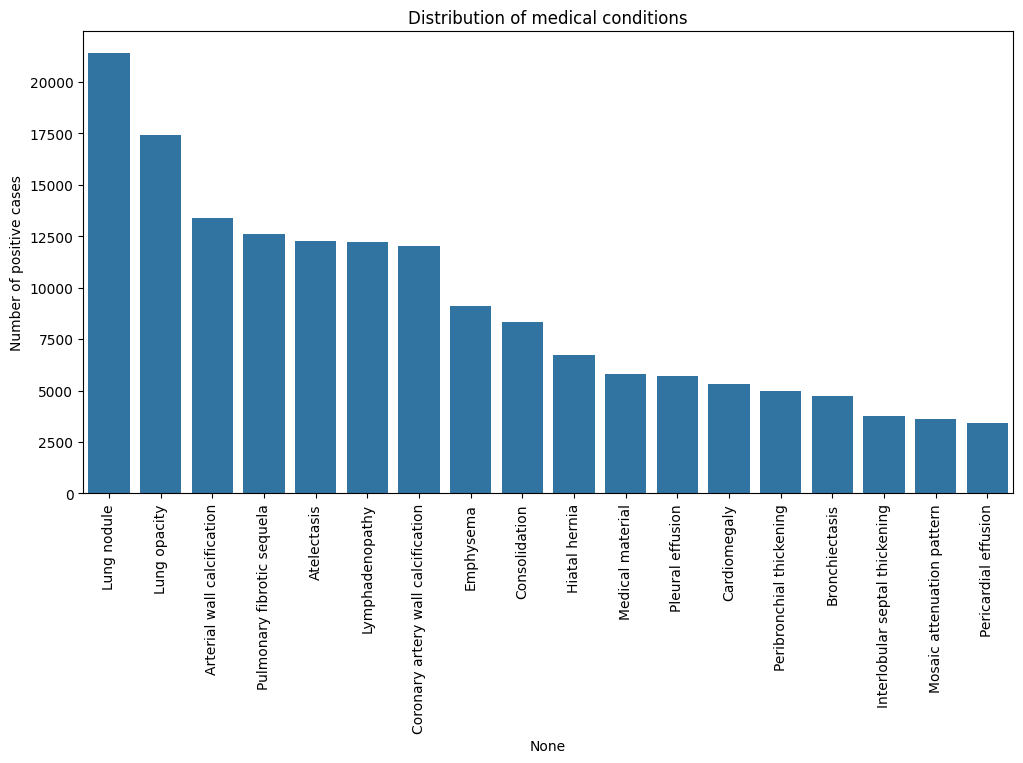

In [7]:
plt.figure(figsize=(12,6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Number of positive cases")
plt.title("Distribution of medical conditions")
plt.show()

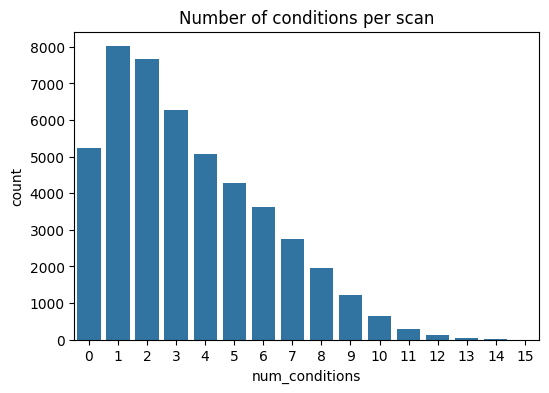

In [8]:
# Count of positive labels per scan
train_labels['num_conditions'] = train_labels.drop("VolumeName", axis=1).sum(axis=1)

plt.figure(figsize=(6,4))
sns.countplot(x='num_conditions', data=train_labels)
plt.title("Number of conditions per scan")
plt.show()

train_labels = train_labels.drop("num_conditions", axis=1)

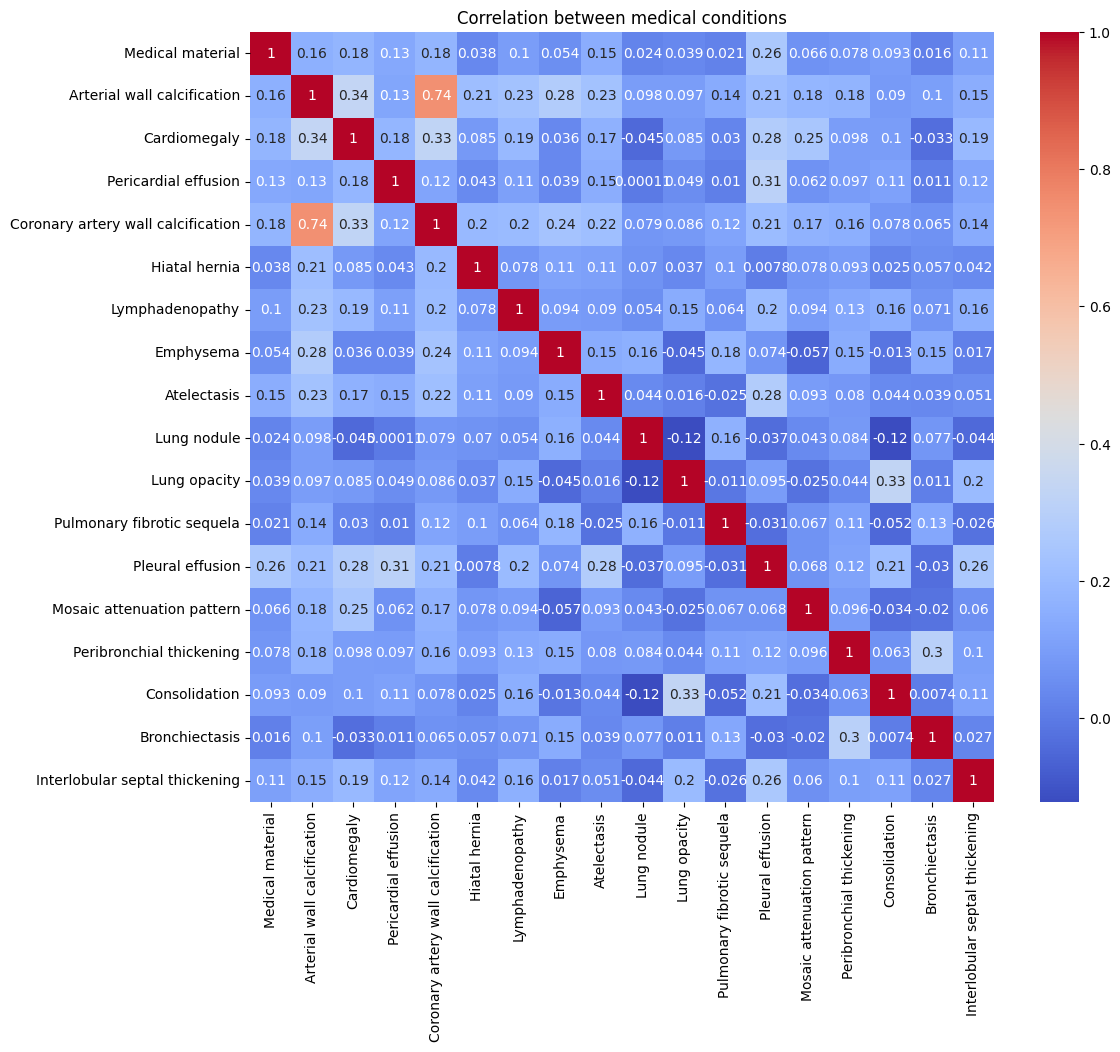

In [9]:
corr_matrix = train_labels.drop("VolumeName", axis=1).corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation between medical conditions")
plt.show()

In [10]:
# Unstack into pairs
corr_pairs = corr_matrix.unstack()

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Remove duplicate pairs
corr_pairs = corr_pairs.to_frame('correlation')
corr_pairs['sorted_index'] = corr_pairs.index.map(lambda x: tuple(sorted(x)))
corr_pairs = corr_pairs.groupby('sorted_index')['correlation'].first()

# Sort by absolute correlation
corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

# Display top correlations
print(corr_pairs.head(10))

sorted_index
(Arterial wall calcification, Coronary artery wall calcification)    0.744473
(Arterial wall calcification, Cardiomegaly)                          0.338042
(Consolidation, Lung opacity)                                        0.329736
(Cardiomegaly, Coronary artery wall calcification)                   0.327012
(Pericardial effusion, Pleural effusion)                             0.311286
(Bronchiectasis, Peribronchial thickening)                           0.301695
(Atelectasis, Pleural effusion)                                      0.280365
(Cardiomegaly, Pleural effusion)                                     0.278330
(Arterial wall calcification, Emphysema)                             0.277502
(Medical material, Pleural effusion)                                 0.259041
Name: correlation, dtype: float64


In [11]:
# check how many scans have Arterial wall calcification but not Coronary artery wall calcification
arterial_only = train_labels[
    (train_labels["Arterial wall calcification"] == 1) &
    (train_labels["Coronary artery wall calcification"] == 0)
]
print(f"Scans with Arterial wall calcification only: {len(arterial_only)}")

# check how many scans have Coronary artery wall calcification but not Arterial wall calcification
coronary_only = train_labels[
    (train_labels["Arterial wall calcification"] == 0) &
    (train_labels["Coronary artery wall calcification"] == 1)
]
print(f"Scans with Coronary artery wall calcification only: {len(coronary_only)}")

# check how many scans have both Arterial and Coronary artery wall calcifications
both = train_labels[
    (train_labels["Arterial wall calcification"] == 1) &
    (train_labels["Coronary artery wall calcification"] == 1)
]
print(f"Scans with both Arterial and Coronary artery wall calcifications: {len(both)}")

Scans with Arterial wall calcification only: 3068
Scans with Coronary artery wall calcification only: 1716
Scans with both Arterial and Coronary artery wall calcifications: 10309


In [12]:
#find list of normal scans with no positive labels
normal_scans = train_labels[
    (train_labels.drop("VolumeName", axis=1).sum(axis=1) == 0)
]
print(f"Number of normal scans with no positive labels: {len(normal_scans)}")

Number of normal scans with no positive labels: 5226


In [13]:
from pathlib import Path

data_volumes_folder_path = Path("/home/chest_ct/code/data/data_volumes/dataset/train_fixed")

# Get all .nii.gz filenames (without full path)
nii_files = [f.name for f in data_volumes_folder_path.rglob("*.nii.gz")]

# Convert dataframe column to a set for fast lookup
normal_scan_names = set(normal_scans["VolumeName"])

# Find matches
matching_files = [f for f in nii_files if f in normal_scan_names]

print("Total .nii.gz files:", len(nii_files))
print("Files found in normal_scans:", len(matching_files))

Total .nii.gz files: 2465
Files found in normal_scans: 348


In [14]:
matching_files

['train_12342_a_1.nii.gz',
 'train_10990_a_1.nii.gz',
 'train_9664_a_1.nii.gz',
 'train_2863_a_1.nii.gz',
 'train_5462_a_2.nii.gz',
 'train_6311_a_2.nii.gz',
 'train_11126_a_1.nii.gz',
 'train_5837_a_1.nii.gz',
 'train_12578_a_2.nii.gz',
 'train_19388_b_2.nii.gz',
 'train_17490_a_1.nii.gz',
 'train_12074_a_2.nii.gz',
 'train_13236_a_2.nii.gz',
 'train_19503_a_4.nii.gz',
 'train_5023_a_2.nii.gz',
 'train_5102_b_2.nii.gz',
 'train_6321_b_2.nii.gz',
 'train_12594_a_2.nii.gz',
 'train_783_a_2.nii.gz',
 'train_783_a_1.nii.gz',
 'train_5864_b_1.nii.gz',
 'train_12132_a_2.nii.gz',
 'train_19988_a_2.nii.gz',
 'train_5637_a_1.nii.gz',
 'train_3779_a_2.nii.gz',
 'train_2822_a_2.nii.gz',
 'train_5039_a_1.nii.gz',
 'train_3528_a_1.nii.gz',
 'train_3528_a_2.nii.gz',
 'train_8785_a_1.nii.gz',
 'train_4381_a_2.nii.gz',
 'train_1033_a_2.nii.gz',
 'train_10566_a_2.nii.gz',
 'train_7553_a_1.nii.gz',
 'train_7277_a_2.nii.gz',
 'train_6845_a_1.nii.gz',
 'train_6997_a_1.nii.gz',
 'train_18696_a_1.nii.gz',


## RexGroundingCT

In [15]:
with open('/home/chest_ct/code/data/rexgrounding-ct/dataset_3.json', 'r') as file:
    rex_data = json.load(file)

rex_train_df = pd.DataFrame(rex_data["train"])
rex_valid_df = pd.DataFrame(rex_data["val"])
rex_test_df = pd.DataFrame(rex_data["test"])
print("RexGrounding-CT Train set size:", len(rex_train_df))
print("RexGrounding-CT Valid set size:", len(rex_valid_df))
print("RexGrounding-CT Test set size:", len(rex_test_df))
print("Total RexGrounding-CT samples:", len(rex_train_df) + len(rex_valid_df) + len(rex_test_df))

RexGrounding-CT Train set size: 1701
RexGrounding-CT Valid set size: 23
RexGrounding-CT Test set size: 41
Total RexGrounding-CT samples: 1765


In [16]:
rex_categories = {
    "1a": "Bronchial wall thickening",
    "1b": "Bronchiectasis",
    "1c": "Emphysema (including centrilobular, paraseptal, bullous)",
    "1d": "Septal thickening (including interlobular septal thickening, reticulation)",
    "1e": "Micronodules (including centrilobular, tree-in-bud, perilymphatic)",
    "1f": "Other non-focal abnormalities",

    "2a": "Linear (including subsegmental atelectasis, scarring, fibrosis)",
    "2b": "Atelectasis, consolidation",
    "2c": "Groundglass opacity",
    "2d": "Pulmonary nodules/masses",
    "2e": "Pleural effusion or thickening",
    "2f": "Honeycombing",
    "2g": "Pneumothorax",
    "2h": "Other focal abnormalities"
}

In [17]:
from collections import Counter

category_counts = Counter()

for split in ["train", "val", "test"]:
    df = pd.DataFrame(rex_data[split])
    
    for cats in df["categories"]:
        category_counts.update(cats.values())

category_df = pd.DataFrame.from_dict(
    category_counts, orient="index", columns=["count"]
).sort_index()

category_df

,count
2b,659
2c,871
2d,908


In [18]:
# find how many normal scans are in rex_data (i.e. scans with no abnormalities)
normal_rex_scans = 0
for split in ["train", "val", "test"]:
    df = pd.DataFrame(rex_data[split])
    
    for cats in df["categories"]:
        if len(cats) == 0:
            normal_rex_scans += 1

print(f"Number of normal scans in RexGrounding-CT: {normal_rex_scans}")

Number of normal scans in RexGrounding-CT: 347


In [19]:
# Add to rex_data original csv, the normal scans from matching_files in the following format:
for volume_name in matching_files:
    if "train" not in rex_data or not isinstance(rex_data["train"], list):
        rex_data["train"] = []

    if not any(entry.get("name") == volume_name for entry in rex_data["train"]):
        rex_data["train"].append({
            "name": volume_name,
            "findings": {},
            "entity_counts": {},
            "shape": [],
            "pixels": {},
            "categories": {},
            "protocol": ""
        })

# Save updated JSON
with open('/home/chest_ct/code/data/rexgrounding-ct/dataset_3.json', 'w') as file:
    json.dump(rex_data, file, indent=2)

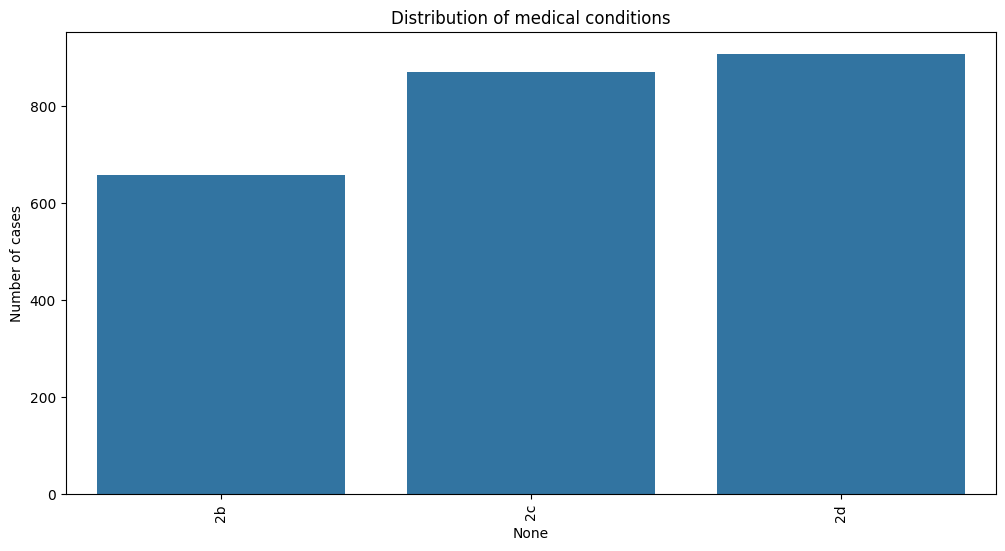

In [20]:
plt.figure(figsize=(12,6))
sns.barplot(x=category_df.index, y=category_df['count'])
plt.xticks(rotation=90)
plt.ylabel("Number of cases")
plt.title("Distribution of medical conditions")
plt.show()

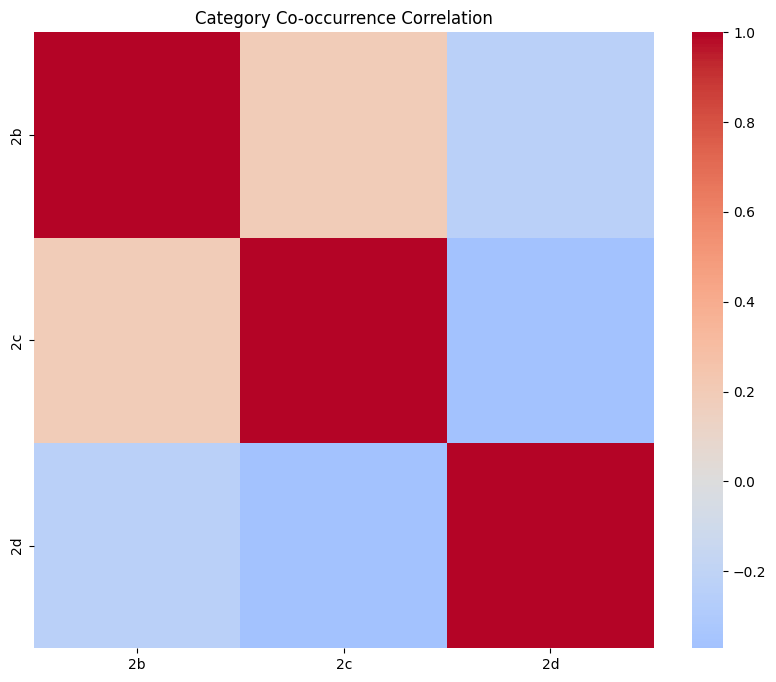

In [21]:
categories = sorted(set(
    cat for split in ["train", "val", "test"]
    for item in rex_data[split]
    for cat in item["categories"].values()
))

rows = []

for split in ["train", "val", "test"]:
    for item in rex_data[split]:
        cats = set(item["categories"].values())
        row = {cat: 1 if cat in cats else 0 for cat in categories}
        rows.append(row)

df = pd.DataFrame(rows)

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Category Co-occurrence Correlation")
plt.show()

In [22]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_pairs = upper.stack().reset_index()
corr_pairs.columns = ["cat1", "cat2", "corr"]

top5 = corr_pairs.sort_values(by="corr", ascending=False).head(5)

top5

,cat1,cat2,corr
1,2b,2c,0.189829
2,2b,2d,-0.237043
5,2c,2d,-0.371619
0,2b,2b,NaN
3,2c,2b,NaN


In [23]:
counts = {}

shortlisted_categories = {"2b", "2c", "2d"}

for split in ["train", "val", "test"]:
    count = 0
    for item in rex_data[split]:
        cats = set(item["categories"].values())
        if cats and cats.issubset(shortlisted_categories):
            count += 1
    counts[split] = count

print(counts)
print("total:", counts["train"] + counts["val"] + counts["test"])

{'train': 1354, 'val': 23, 'test': 41}
total: 1418


In [24]:
category_counts = Counter()

for split in ["train", "val", "test"]:
    for item in rex_data[split]:
        cats = item["categories"].values()
        cats_set = set(cats)
        
        # keep only scans fully inside shortlist
        if cats_set and cats_set.issubset(shortlisted_categories):
            category_counts.update(cats)

shortlisted_category_df = (
    pd.DataFrame.from_dict(category_counts, orient="index", columns=["count"])
    .sort_index()
)

shortlisted_category_df

,count
2b,659
2c,871
2d,908


CT shape: (512, 512, 204)
SEG shape: (5, 512, 512, 204)
Selected mask shape: (512, 512, 204)


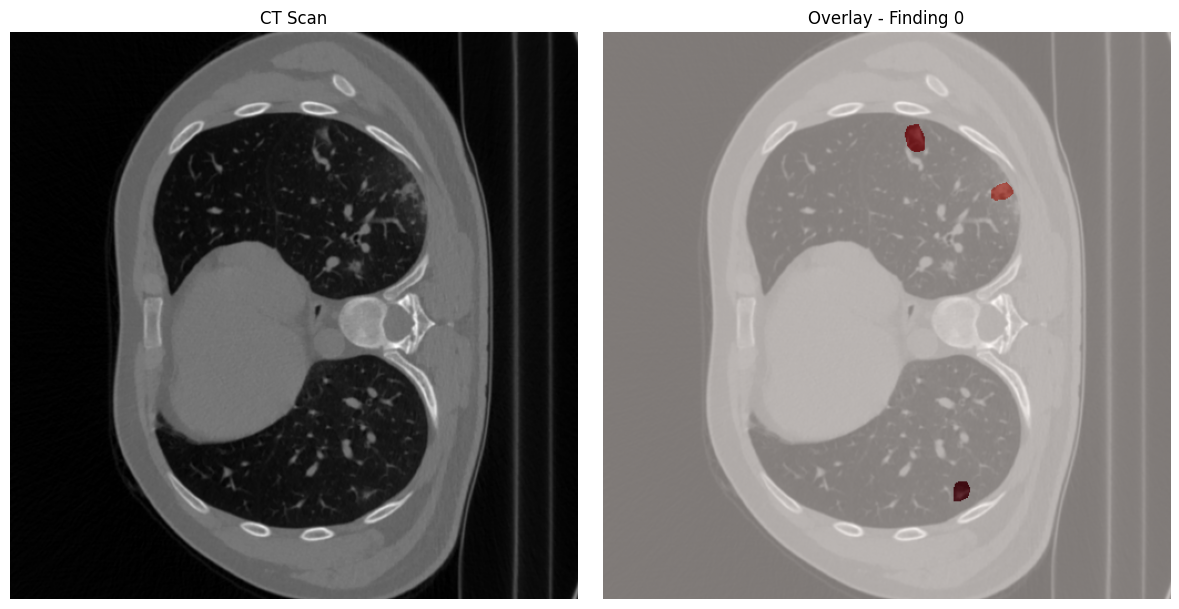

In [34]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

demo_ct_path = "/home/chest_ct/code/data/data_volumes/dataset/train_fixed/train_12991/train_12991_a/train_12991_a_1.nii.gz"
demo_segmentation_path = "/home/chest_ct/code/data/segmentations/segmentations/train_12991_a_1.nii.gz"

# Load data
ct_data = nib.load(demo_ct_path).get_fdata()
seg_data = nib.load(demo_segmentation_path).get_fdata()

print("CT shape:", ct_data.shape)
print("SEG shape:", seg_data.shape)

# Select a finding/channel
finding_idx = 0
seg_mask = seg_data[finding_idx]

print("Selected mask shape:", seg_mask.shape)

# Find slices containing the segmentation
seg_slices = np.where(seg_mask.sum(axis=(0, 1)) > 0)[0]

if len(seg_slices) == 0:
    raise ValueError("No segmentation found for this finding")

# Middle slice containing lesion
middle_slice = seg_slices[len(seg_slices) // 2]

# Plot
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(ct_data[:, :, middle_slice], cmap="gray")
plt.title("CT Scan")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ct_data[:, :, middle_slice], cmap="gray")
plt.imshow(seg_mask[:, :, middle_slice], cmap="Reds", alpha=0.5)
plt.title(f"Overlay - Finding {finding_idx}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
# find the dimensions of the scans in the shortlisted categories
scan_dimensions = []

for split in ["train"]:
    for item in rex_data[split][:100]:
        print(f"checking scan: {item['name']}")

        cats = set(item["categories"].values())

        if cats and cats.issubset(shortlisted_categories):
            scan_name = item["name"]

            matches = list(
                data_volumes_folder_path.rglob(scan_name)
            )

            if matches:
                scan = nib.load(matches[0])
                scan_dimensions.append(scan.shape)

print(scan_dimensions[:5])
print(len(scan_dimensions))

checking scan: train_1741_b_2.nii.gz
checking scan: train_1591_f_2.nii.gz
checking scan: train_1741_c_2.nii.gz
checking scan: train_2239_a_2.nii.gz
checking scan: train_1591_c_2.nii.gz
checking scan: train_1785_a_2.nii.gz
checking scan: train_1959_b_2.nii.gz
checking scan: train_1661_b_1.nii.gz
checking scan: train_1676_a_2.nii.gz
checking scan: train_1544_a_1.nii.gz
checking scan: train_2256_a_2.nii.gz
checking scan: train_2394_a_1.nii.gz
checking scan: train_2226_a_1.nii.gz
checking scan: train_1296_a_2.nii.gz
checking scan: train_1349_a_2.nii.gz
checking scan: train_1696_a_2.nii.gz
checking scan: train_2381_a_2.nii.gz
checking scan: train_1606_a_2.nii.gz
checking scan: train_1860_a_1.nii.gz
checking scan: train_1427_a_2.nii.gz
checking scan: train_2111_a_1.nii.gz
checking scan: train_1850_a_1.nii.gz
checking scan: train_1441_a_2.nii.gz
checking scan: train_1823_a_2.nii.gz
checking scan: train_2039_a_2.nii.gz
checking scan: train_1580_a_2.nii.gz
checking scan: train_2347_a_1.nii.gz
c

In [26]:
print(scan.shape)
print(scan.header.get_zooms())

(512, 512, 220)
(np.float32(0.7402344), np.float32(0.7402344), np.float32(1.5))


In [27]:
# find the number of patches per category in the shortlisted categories
# A patch is 32x32x32 voxels. 
# segmentations_folder_path gives the segmentation masks for each scan. We can use these masks to count the number of patches that contain each category.

patch_size = 32
patch_df = pd.DataFrame(columns=["scan_name", "finding", "category", "patch_count"])

def pad_to_multiple(arr, m=32):
    pad = [(0, (m - s % m) % m) for s in arr.shape]
    return np.pad(arr, pad, mode="constant", constant_values=0)


def count_patches_3d(mask3d, patch_size=32):
    mask3d = pad_to_multiple(mask3d, patch_size)

    sx, sy, sz = mask3d.shape

    patches = mask3d.reshape(
        sx // patch_size, patch_size,
        sy // patch_size, patch_size,
        sz // patch_size, patch_size
    )

    patches = patches.transpose(0, 2, 4, 1, 3, 5)
    patches = patches.reshape(-1, patch_size, patch_size, patch_size)

    return np.sum(np.any(patches, axis=(1, 2, 3)))


for split in ["train"][:10]:
    for item in rex_data[split]:

        scan_name = item["name"]
        categories = item["categories"]

        print(f"\nchecking scan: {scan_name}")

        seg_matches = list(Path(segmentations_folder_path).rglob(scan_name))
        if not seg_matches:
            continue

        seg = nib.load(seg_matches[0]).get_fdata()

        print("seg shape:", seg.shape)

        # seg is (F, H, W, D)
        F = seg.shape[0]

        for f in range(F):

            cat = categories.get(str(f), None)

            if cat is None:
                continue

            if cat not in shortlisted_categories:
                continue

            mask3d = seg[f]

            # treat each finding as foreground mask
            mask3d = (mask3d > 0).astype(np.uint8)

            patch_count = count_patches_3d(mask3d, patch_size)

            print(f"Scan: {scan_name}, Finding: {f}, Category: {cat}, Patches: {patch_count}")

            patch_df = pd.concat(
                [
                    patch_df,
                    pd.DataFrame([{
                        "scan_name": scan_name,
                        "finding": f,
                        "category": cat,
                        "patch_count": patch_count
                    }])
                ],
                ignore_index=True
            )


checking scan: train_1741_b_2.nii.gz
seg shape: (1, 512, 512, 238)
Scan: train_1741_b_2.nii.gz, Finding: 0, Category: 2b, Patches: 6

checking scan: train_1591_f_2.nii.gz
seg shape: (5, 512, 512, 466)
Scan: train_1591_f_2.nii.gz, Finding: 0, Category: 2b, Patches: 22
Scan: train_1591_f_2.nii.gz, Finding: 1, Category: 2b, Patches: 14
Scan: train_1591_f_2.nii.gz, Finding: 2, Category: 2b, Patches: 4
Scan: train_1591_f_2.nii.gz, Finding: 3, Category: 2b, Patches: 14
Scan: train_1591_f_2.nii.gz, Finding: 4, Category: 2b, Patches: 13

checking scan: train_1741_c_2.nii.gz
seg shape: (2, 512, 512, 247)
Scan: train_1741_c_2.nii.gz, Finding: 0, Category: 2b, Patches: 16
Scan: train_1741_c_2.nii.gz, Finding: 1, Category: 2d, Patches: 3

checking scan: train_2239_a_2.nii.gz
seg shape: (1, 512, 512, 412)
Scan: train_2239_a_2.nii.gz, Finding: 0, Category: 2c, Patches: 62

checking scan: train_1591_c_2.nii.gz
seg shape: (6, 512, 512, 463)
Scan: train_1591_c_2.nii.gz, Finding: 0, Category: 2b, Patch

KeyboardInterrupt: 

In [ ]:
patch_df

,scan_name,finding,category,patch_count
0,train_1741_b_2.nii.gz,0,2b,6
1,train_1591_f_2.nii.gz,0,2b,22
2,train_1591_f_2.nii.gz,1,2b,14
3,train_1591_f_2.nii.gz,2,2b,4
4,train_1591_f_2.nii.gz,3,2b,14
...,...,...,...,...
2331,train_929_a_1.nii.gz,0,2c,53
2332,valid_915_b_2.nii.gz,0,2d,1
2333,valid_915_b_2.nii.gz,1,2d,2
2334,train_1053_a_1.nii.gz,0,2c,25


In [ ]:
# # create csv from patch_df
# patch_df.to_csv("/home/chest_ct/code/models/patch_counts.csv", index=False)

In [ ]:
total_patches_per_category = (
    patch_df.groupby("category")["patch_count"]
    .sum()
    .reset_index()
)

print(total_patches_per_category)

  category patch_count
0       2b       16392
1       2c       20371
2       2d        4011


In [ ]:
# patch_size = 32

# from collections import defaultdict

# category_patch_counts = defaultdict(int)

# def pad_to_multiple(arr, m=32):
#     pad = [(0, (m - s % m) % m) for s in arr.shape]
#     return np.pad(arr, pad, mode="constant", constant_values=0)


# def count_patches_3d(mask3d, patch_size=32):
#     mask3d = pad_to_multiple(mask3d, patch_size)

#     sx, sy, sz = mask3d.shape

#     patches = mask3d.reshape(
#         sx // patch_size, patch_size,
#         sy // patch_size, patch_size,
#         sz // patch_size, patch_size
#     )

#     patches = patches.transpose(0, 2, 4, 1, 3, 5)
#     patches = patches.reshape(-1, patch_size, patch_size, patch_size)

#     return np.sum(np.any(patches, axis=(1, 2, 3)))


# for split in ["train"]:
#     for item in rex_data[split][:10]:

#         scan_name = item["name"]
#         cats = set(item["categories"].values())

#         print(f"\nchecking scan: {scan_name}")

#         seg_matches = list(Path(segmentations_folder_path).rglob(scan_name))
#         if not seg_matches:
#             continue

#         seg = nib.load(seg_matches[0]).get_fdata()

#         # seg shape: (F, H, W, D)
#         print("seg shape:", seg.shape)

#         findings, H, W, D = seg.shape

#         for f in range(findings):
#             mask3d = seg[f]

#             # binary mask per finding
#             mask3d = (mask3d > 0).astype(np.uint8)

#             patch_count = count_patches_3d(mask3d, patch_size)

#             category = item["categories"][str(f)]
#             category_patch_counts[category] += patch_count

# for cat, total_patches in category_patch_counts.items():
#     print(cat, total_patches)

In [ ]:
# # Add CT-RATE normal scans into RexGroundingCT metadata (train split)
# dataset_path = "/home/chest_ct/code/data/rexgrounding-ct/dataset_new.json"

# # `normal_scans` was created above as a filtered DataFrame; extract VolumeName list
# normal_scan_names = normal_scans["VolumeName"].astype(str).tolist()

# with open(dataset_path, "r") as f:
#     metadata = json.load(f)

# # Ensure expected split exists
# if "train" not in metadata or not isinstance(metadata["train"], list):
#     metadata["train"] = []

# # Avoid duplicates by existing scan name
# existing_names = {item.get("name", "") for item in metadata["train"] if isinstance(item, dict)}

# new_entries = []
# for scan_name in normal_scan_names:
#     name = scan_name if scan_name.endswith(".nii.gz") else f"{scan_name}.nii.gz"
#     if name in existing_names:
#         continue

#     new_entries.append({
#         "name": name,
#         "findings": {},
#         "entity_counts": {},
#         "pixels": {},
#         "categories": {},
#         "shape": [512, 512, 264],
#         "protocol": "protocol1",
#     })

# metadata["train"].extend(new_entries)

# with open(dataset_path, "w") as f:
#     json.dump(metadata, f, indent=2)

# print(f"Added {len(new_entries)} normal scans to train split in {dataset_path}")
# print(f"Train split total: {len(metadata['train'])}")

## LC-KSVD localization